# Étape 3 — Extraction des caractéristiques

Ce notebook couvre les **approches traditionnelles** d'extraction de features faciaux :
1. **Haar Cascade (Viola-Jones)** : filtres en cascade pour la détection de motifs faciaux
2. **Local Binary Patterns (LBP)** : analyse des textures locales
3. **Histogram of Oriented Gradients (HOG)** : structures et formes via histogrammes de gradients


## 0. Imports et configuration

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import cv2
from skimage.feature import local_binary_pattern, hog
from skimage import exposure
from sklearn.datasets import fetch_lfw_people

# ── Matplotlib defaults ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"OpenCV    : {cv2.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

OpenCV    : 4.13.0
NumPy     : 2.3.5
Matplotlib: 3.10.6


---
## Chargement des données prétraitées

On réutilise le dataset LFW chargé à l'étape 1 et on applique le pipeline de prétraitement
de l'étape 2 pour obtenir des images prêtes à l'extraction de features.

In [2]:
# ── Chargement du dataset LFW ─────────────────────────────────────────────────
print("Chargement du dataset LFW…")
lfw = fetch_lfw_people(
    min_faces_per_person=20,
    color=True,
    resize=1.0,
    data_home=os.path.join('.', 'data'),
)
images = lfw.images
labels = lfw.target
names  = lfw.target_names
N, H, W, C = images.shape
print(f"Dataset chargé : {N} images, {len(names)} identités, résolution {H}×{W}")


# ── Fonctions utilitaires ─────────────────────────────────────────────────────
def lfw_to_bgr(img_rgb_float):
    """Convertit une image LFW (RGB float32 [0,1]) → BGR uint8."""
    img_uint8 = (img_rgb_float * 255).clip(0, 255).astype(np.uint8)
    return cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

def bgr_to_rgb(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


# ── Pipeline de prétraitement (repris de l'étape 2) ──────────────────────────
haar_path    = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haar_path)

TARGET_SIZE = (128, 128)

def preprocess(bgr_img, target_size=TARGET_SIZE):
    """
    Détection → recadrage → niveaux de gris → débruitage → CLAHE
    → redimensionnement → normalisation.
    Retourne une image float32 [0,1] de taille target_size, ou None.
    """
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) == 0:
        return None
    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    face = bgr_img[y:y+h, x:x+w]
    gray_face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    denoised  = cv2.GaussianBlur(gray_face, (3, 3), 0)
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(denoised)
    resized   = cv2.resize(equalized, target_size, interpolation=cv2.INTER_LINEAR)
    return resized.astype(np.float32) / 255.0


# ── Construction d'un échantillon prétraité ───────────────────────────────────
sample_faces, sample_labels = [], []
for i, img_rgb in enumerate(images):
    face = preprocess(lfw_to_bgr(img_rgb))
    if face is not None:
        sample_faces.append(face)
        sample_labels.append(labels[i])
    if len(sample_faces) == 200:   # on prend 200 images détectées
        break

sample_faces  = np.array(sample_faces)
sample_labels = np.array(sample_labels)
print(f"\nÉchantillon prétraité : {len(sample_faces)} images disponibles pour l'extraction.")

Chargement du dataset LFW…
Dataset chargé : 3023 images, 62 identités, résolution 125×94

Échantillon prétraité : 200 images disponibles pour l'extraction.


---
## 3.1 Approches traditionnelles

### 3a. Haar Cascade (Viola-Jones) — détection de motifs faciaux

L'algorithme **Viola-Jones** applique des *features Haar* (différences de sommes
de pixels sur des régions rectangulaires) organisées en cascade pour détecter
des motifs caractéristiques du visage (zone des yeux, arête du nez, bouche).

**Principe de la feature Haar :**
```
score = Σ pixels zone claire − Σ pixels zone sombre
```
L'image intégrale permet ce calcul en O(1) quelle que soit la taille du rectangle.
La cascade rejette ~60 % des fenêtres dès l'étape 1 (2 features seulement),
ce qui rend la détection temps-réel possible.

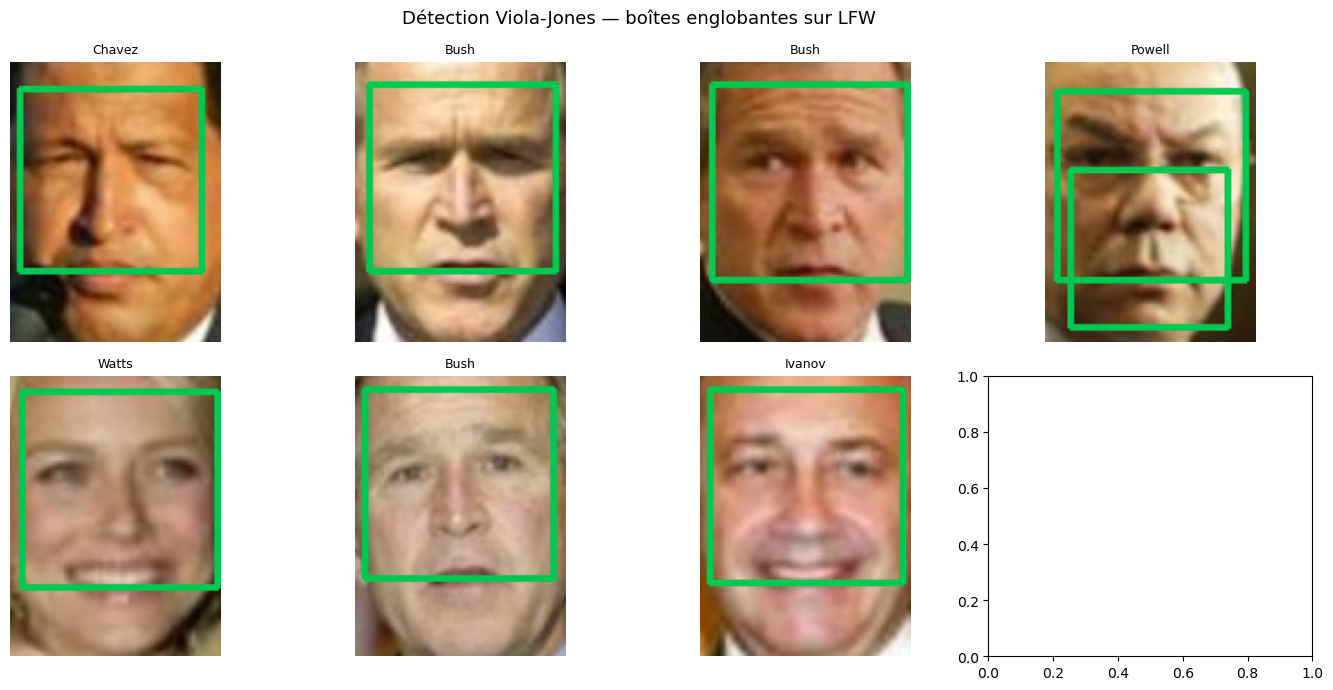

In [3]:
# ── Visualisation des boîtes de détection Haar ────────────────────────────────
# On affiche 8 images LFW avec les bounding boxes détectées par Viola-Jones.

n_demo = 8
rng    = np.random.default_rng(RANDOM_STATE)
idx    = rng.choice(N, n_demo * 3, replace=False)  # pool large pour trouver 8 détections

detected_demos = []
for i in idx:
    bgr  = lfw_to_bgr(images[i])
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) > 0:
        detected_demos.append((bgr, faces, names[labels[i]]))
    if len(detected_demos) == n_demo:
        break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Détection Viola-Jones — boîtes englobantes sur LFW", fontsize=13)

for ax, (bgr, faces, name) in zip(axes.ravel(), detected_demos):
    display = bgr_to_rgb(bgr.copy())
    for (x, y, w, h) in faces:
        cv2.rectangle(display, (x, y), (x+w, y+h), (0, 200, 80), 2)
    ax.imshow(display)
    ax.set_title(name.split()[-1], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# ── Statistiques de détection Haar sur le dataset complet ─────────────────────
detected, not_detected = 0, 0
for img_rgb in images:
    bgr  = lfw_to_bgr(img_rgb)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) > 0:
        detected += 1
    else:
        not_detected += 1

taux = detected / N * 100
print(f"Taux de détection Viola-Jones sur LFW : {detected}/{N} ({taux:.1f} %)")
print(f"Non détectés : {not_detected} images")
print()
print("Note : LFW contient des visages en profil, partiellement occultés")
print("ou sous éclairage difficile — la cascade frontale n'y répond pas.")

Taux de détection Viola-Jones sur LFW : 869/3023 (28.7 %)
Non détectés : 2154 images

Note : LFW contient des visages en profil, partiellement occultés
ou sous éclairage difficile — la cascade frontale n'y répond pas.


---
### 3b. Local Binary Patterns (LBP) — texture locale

LBP encode la **texture locale** d'un pixel en comparant son intensité à ses
voisins sur un cercle de rayon `r`. On obtient un code binaire par pixel,
puis un **histogramme normalisé** sur l'ensemble de l'image.

**Propriétés clés :**
- Robuste aux variations d'éclairage (comparaisons relatives)
- Très faible coût de calcul
- Vecteur de sortie : `n_points + 2` bins (mode `uniform`)

**Paramètres utilisés dans le projet :**

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `radius`  | 1      | Rayon du voisinage circulaire |
| `n_points`| 8      | Nombre de points d'échantillonnage |
| `method`  | uniform| Réduit les codes à 58 + 1 patterns |
| `n_bins`  | 256    | Taille de l'histogramme |

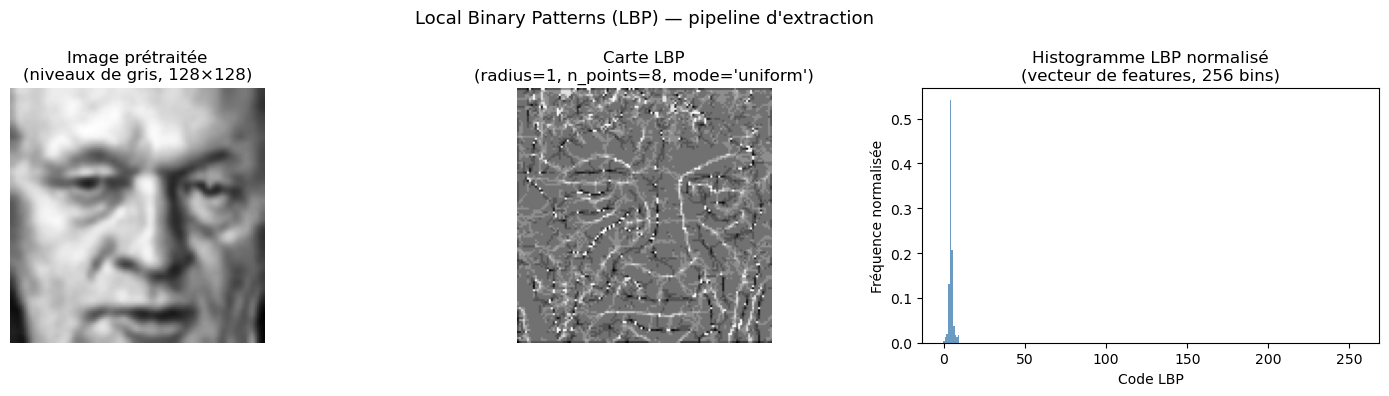

Taille du vecteur LBP : 256 dimensions


In [5]:
# ── Calcul et visualisation LBP ───────────────────────────────────────────────
LBP_RADIUS   = 1
LBP_N_POINTS = 8 * LBP_RADIUS
N_BINS       = 256

# Image de démonstration : première image prétraitée
demo_face = sample_faces[0]                        # float32 [0,1]
demo_uint8 = (demo_face * 255).clip(0,255).astype(np.uint8)

lbp_image = local_binary_pattern(
    demo_uint8, LBP_N_POINTS, LBP_RADIUS, method='uniform'
)

hist, bins = np.histogram(lbp_image.ravel(), bins=N_BINS, range=(0, N_BINS))
hist = hist.astype(np.float32)
hist /= hist.sum() + 1e-7   # normalisation L1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Local Binary Patterns (LBP) — pipeline d'extraction", fontsize=13)

axes[0].imshow(demo_face, cmap='gray')
axes[0].set_title("Image prétraitée\n(niveaux de gris, 128×128)")
axes[0].axis('off')

axes[1].imshow(lbp_image, cmap='gray')
axes[1].set_title(f"Carte LBP\n(radius={LBP_RADIUS}, n_points={LBP_N_POINTS}, mode='uniform')")
axes[1].axis('off')

axes[2].bar(range(N_BINS), hist, width=1.0, color='steelblue', alpha=0.8)
axes[2].set_title(f"Histogramme LBP normalisé\n(vecteur de features, {N_BINS} bins)")
axes[2].set_xlabel("Code LBP")
axes[2].set_ylabel("Fréquence normalisée")

plt.tight_layout()
plt.show()

print(f"Taille du vecteur LBP : {hist.shape[0]} dimensions")

In [6]:
# ── Extraction LBP sur tout l'échantillon ────────────────────────────────────
def extract_lbp(face_float32, radius=LBP_RADIUS, n_points=LBP_N_POINTS, n_bins=N_BINS):
    """Retourne l'histogramme LBP normalisé (float32, shape=(n_bins,))."""
    uint8 = (face_float32 * 255).clip(0,255).astype(np.uint8)
    lbp   = local_binary_pattern(uint8, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    hist /= hist.sum() + 1e-7
    return hist

X_lbp = np.array([extract_lbp(f) for f in sample_faces])
print(f"Matrice de features LBP : {X_lbp.shape}")
print(f"  → {X_lbp.shape[0]} images  ×  {X_lbp.shape[1]} dimensions")

Matrice de features LBP : (200, 256)
  → 200 images  ×  256 dimensions


---
### 3c. Histogram of Oriented Gradients (HOG) — formes et structures

HOG capture les **orientations de gradients** (contours, formes) dans des cellules
locales, puis normalise les histogrammes par blocs pour une invariance partielle
à l'éclairage et au contraste.

**Pipeline HOG :**
1. Calcul des gradients (Gx, Gy) par dérivée discrète
2. Orientation θ = arctan(Gy/Gx) et amplitude |G|
3. Histogramme d'orientations par cellule (8×8 pixels)
4. Normalisation L2 par blocs de 2×2 cellules
5. Concaténation → vecteur final

**Paramètres :**

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `orientations` | 9 | Nombre de bins d'angle (0°–180°) |
| `pixels_per_cell` | (8, 8) | Taille d'une cellule |
| `cells_per_block` | (2, 2) | Blocs de normalisation |
| `block_norm` | L2-Hys | Normalisation robuste |

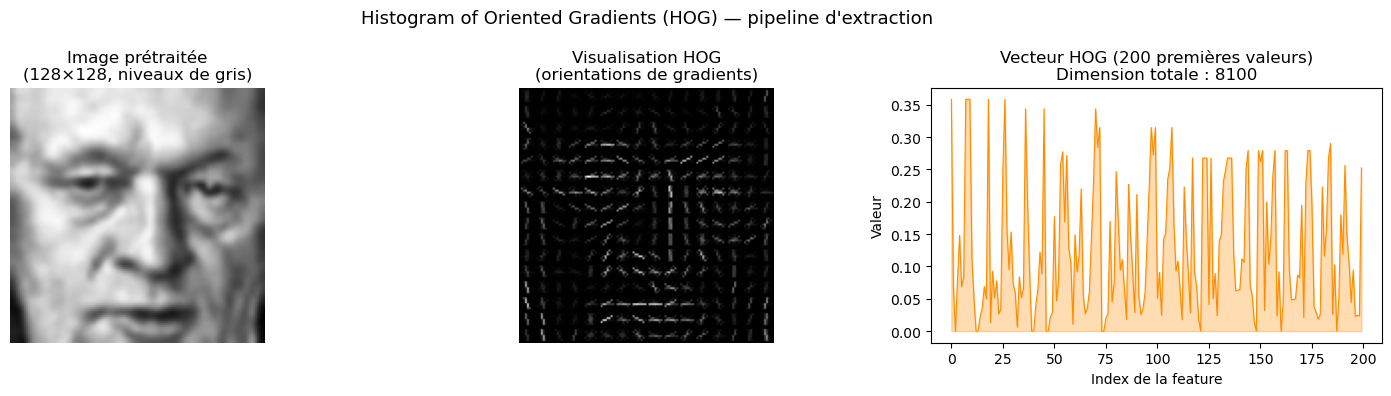

Taille du vecteur HOG : 8100 dimensions


In [7]:
# ── Calcul et visualisation HOG ───────────────────────────────────────────────
HOG_ORIENTATIONS     = 9
HOG_PIXELS_PER_CELL  = (8, 8)
HOG_CELLS_PER_BLOCK  = (2, 2)

hog_features, hog_image = hog(
    demo_face,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm='L2-Hys',
    visualize=True,
    feature_vector=True,
)

# Amélioration du contraste pour visualisation
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Histogram of Oriented Gradients (HOG) — pipeline d'extraction", fontsize=13)

axes[0].imshow(demo_face, cmap='gray')
axes[0].set_title("Image prétraitée\n(128×128, niveaux de gris)")
axes[0].axis('off')

axes[1].imshow(hog_image_rescaled, cmap='gray')
axes[1].set_title("Visualisation HOG\n(orientations de gradients)")
axes[1].axis('off')

axes[2].plot(hog_features[:200], color='darkorange', linewidth=0.8)
axes[2].fill_between(range(200), hog_features[:200], alpha=0.3, color='darkorange')
axes[2].set_title(f"Vecteur HOG (200 premières valeurs)\nDimension totale : {len(hog_features)}")
axes[2].set_xlabel("Index de la feature")
axes[2].set_ylabel("Valeur")

plt.tight_layout()
plt.show()

print(f"Taille du vecteur HOG : {hog_features.shape[0]} dimensions")

In [8]:
# ── Extraction HOG sur tout l'échantillon ────────────────────────────────────
def extract_hog(face_float32):
    """Retourne le vecteur HOG (float64 normalisé)."""
    features = hog(
        face_float32,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        feature_vector=True,
    )
    return features.astype(np.float32)

X_hog = np.array([extract_hog(f) for f in sample_faces])
print(f"Matrice de features HOG : {X_hog.shape}")
print(f"  → {X_hog.shape[0]} images  ×  {X_hog.shape[1]} dimensions")

Matrice de features HOG : (200, 8100)
  → 200 images  ×  8100 dimensions


---
## Comparaison des approches — résumé visuel

On compare côte à côte les vecteurs LBP et HOG extraits sur la même image.


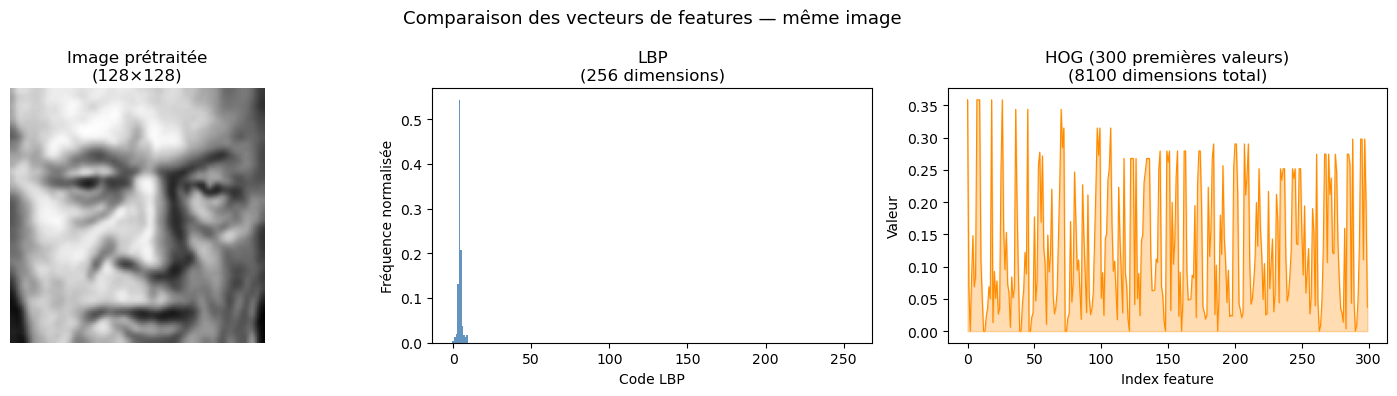

In [9]:
# ── Comparaison des vecteurs de features sur une même image ───────────────────
face_demo = sample_faces[0]
lbp_feat  = extract_lbp(face_demo)
hog_feat  = extract_hog(face_demo)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Comparaison des vecteurs de features — même image", fontsize=13)

axes[0].imshow(face_demo, cmap='gray')
axes[0].set_title("Image prétraitée\n(128×128)")
axes[0].axis('off')

axes[1].bar(range(len(lbp_feat)), lbp_feat, width=1.0, color='steelblue', alpha=0.85)
axes[1].set_title(f"LBP\n({len(lbp_feat)} dimensions)")
axes[1].set_xlabel("Code LBP")
axes[1].set_ylabel("Fréquence normalisée")

axes[2].plot(hog_feat[:300], color='darkorange', linewidth=0.8)
axes[2].fill_between(range(300), hog_feat[:300], alpha=0.3, color='darkorange')
axes[2].set_title(f"HOG (300 premières valeurs)\n({len(hog_feat)} dimensions total)")
axes[2].set_xlabel("Index feature")
axes[2].set_ylabel("Valeur")

plt.tight_layout()
plt.show()


---
## Bilan

| Méthode | Type | Dimensions | Robustesse éclairage | Vitesse | Usage |
|---------|------|-----------|----------------------|---------|-------|
| **Haar Cascade** | Traditionnel | N/A (détection) | Faible | Très rapide | Détection de visages |
| **LBP** | Traditionnel | 256 | Robuste | Rapide | Reconnaissance |
| **HOG** | Traditionnel | ~3 780* | Moyenne | Moyen | Détection + Reconnaissance |

*Pour une image 128×128, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2).

**Conclusion** : LBP et HOG sont interprétables et légers, adaptés aux systèmes embarqués.
Haar localise rapidement les visages, LBP et HOG fournissent des vecteurs de features
utilisables directement par les classifieurs SVM et KNN définis dans les modules  du projet.
